# Multi-Strategy Portfolio Combiner

Each prior notebook documented a single sleeve in isolation: a long-short S&P 500 equity book (notebooks 01-04), a crypto vol-momentum overlay (notebook 07), and a stat-arb pairs book (notebook 09). This notebook treats them as three independent return streams and asks the only question that matters at the fund level: what does the combined PnL look like when each sleeve is sized with one of three textbook portfolio rules.

The three rules are fixed in advance and applied as-is: equal-weight, inverse trailing-vol (risk parity), and long-only minimum-variance with a 252-day rolling covariance. No grid is searched, no parameters are tuned. The diversification benefit, if any, comes from the sleeves having low cross-correlation rather than from finding a clever weighting scheme. A fund-of-strategies view is the honest aggregation level: per-sleeve Sharpes can be inflated by selection effects within each sleeve's research notebook, but the cross-sleeve combination adds no extra degrees of freedom once the rules are fixed.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from multi_strategy import (
    load_sleeve_pnls,
    combine_equal_weight,
    combine_inverse_vol,
    combine_min_variance,
    evaluate_combination,
)

pd.set_option('display.float_format', '{:.4f}'.format)

## Load Sleeves

The equity sleeve is recomputed from the saved per-signal OOS weights (notebook 04 does not persist its combined PnL). Crypto and pairs sleeves load directly from disk. All three streams are aligned on the intersection of their date indices so each combination rule sees an identical date set.

In [2]:
sleeves = load_sleeve_pnls()
print('Sleeve keys:', list(sleeves.keys()))

panel = pd.concat(sleeves, axis=1)
print(f'Panel shape: {panel.shape}')
print(f'Date range: {panel.index.min().date()}  ->  {panel.index.max().date()}')
panel.head()

Sleeve keys: ['equity', 'crypto', 'pairs']
Panel shape: (1315, 3)
Date range: 2021-01-05  ->  2026-03-31


,equity,crypto,pairs
2021-01-05,0.0060,0.0116,0.0000
2021-01-06,-0.0007,0.0370,0.0000
2021-01-07,0.0030,-0.1020,0.0000
2021-01-08,-0.0025,0.0649,0.0000
2021-01-11,0.0047,-0.0448,0.0000


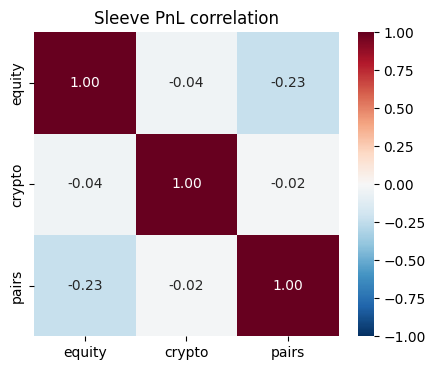

,equity,crypto,pairs
equity,1.0000,-0.0430,-0.2290
crypto,-0.0430,1.0000,-0.0210
pairs,-0.2290,-0.0210,1.0000


In [3]:
# Cross-sleeve PnL correlation. Low magnitudes mean the sleeves' errors
# are roughly independent, which is the precondition for diversification
# to actually help at the portfolio level.
corr = panel.corr()

fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Sleeve PnL correlation')
plt.tight_layout()
plt.show()

corr.round(3)

## Three Combination Rules

All three rules apply weights computed from data strictly through t-1 and earn the day-t return. The inverse-vol rule uses a 60-day trailing standard deviation per sleeve. The minimum-variance rule uses a 252-day sample covariance and enforces long-only weights that sum to one (no leverage, no shorting one sleeve to fund another). Burn-in dates with insufficient history are dropped.

In [4]:
pnl_ew = combine_equal_weight(sleeves)
pnl_iv = combine_inverse_vol(sleeves, lookback=60)
pnl_mv = combine_min_variance(sleeves, lookback=252)

print(f'Equal-weight     : {len(pnl_ew):4d} days, {pnl_ew.index.min().date()} -> {pnl_ew.index.max().date()}')
print(f'Inverse-vol (60) : {len(pnl_iv):4d} days, {pnl_iv.index.min().date()} -> {pnl_iv.index.max().date()}')
print(f'Min-variance(252): {len(pnl_mv):4d} days, {pnl_mv.index.min().date()} -> {pnl_mv.index.max().date()}')

/Users/sashrikrajesh/Documents/sashrikrajesh/apps/quantresearch/research/../multi_strategy.py:196: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  prob.solve(solver=cp.SCS, warm_start=True)


Equal-weight     : 1315 days, 2021-01-05 -> 2026-03-31
Inverse-vol (60) : 1255 days, 2021-04-01 -> 2026-03-31
Min-variance(252): 1062 days, 2022-01-05 -> 2026-03-31


## Comparison Table

Sharpe annualised at 252 periods/year because the equity sleeve dominates the calendar (the inner-join collapses to business days). HAC alpha t-stat is computed against SPY with five Newey-West lags.

In [5]:
spy = pd.read_parquet('../data/spy.parquet')['Close'].squeeze().pct_change()

rows = []
for label, p in [('equal_weight', pnl_ew), ('inverse_vol', pnl_iv), ('min_variance', pnl_mv)]:
    bench = spy.reindex(p.index)
    rows.append(evaluate_combination(p, label, benchmark=bench, periods_per_year=252))

results = pd.DataFrame(rows).set_index('label')
results

,sharpe,ann_vol,ann_return,max_dd,skew,kurt,n_days,alpha_annual,alpha_tstat_hac,beta
label,,,,,,,,,,
equal_weight,0.0360,18.10%,0.64%,-27.95%,-8.1210,191.4210,1315,2.32%,0.3170,-0.1230
inverse_vol,0.6370,8.56%,5.45%,-11.39%,0.0660,2.8630,1255,5.88%,1.6330,-0.0340
min_variance,0.6970,8.08%,5.63%,-8.31%,-0.0850,2.4070,1062,5.34%,1.4540,0.0280


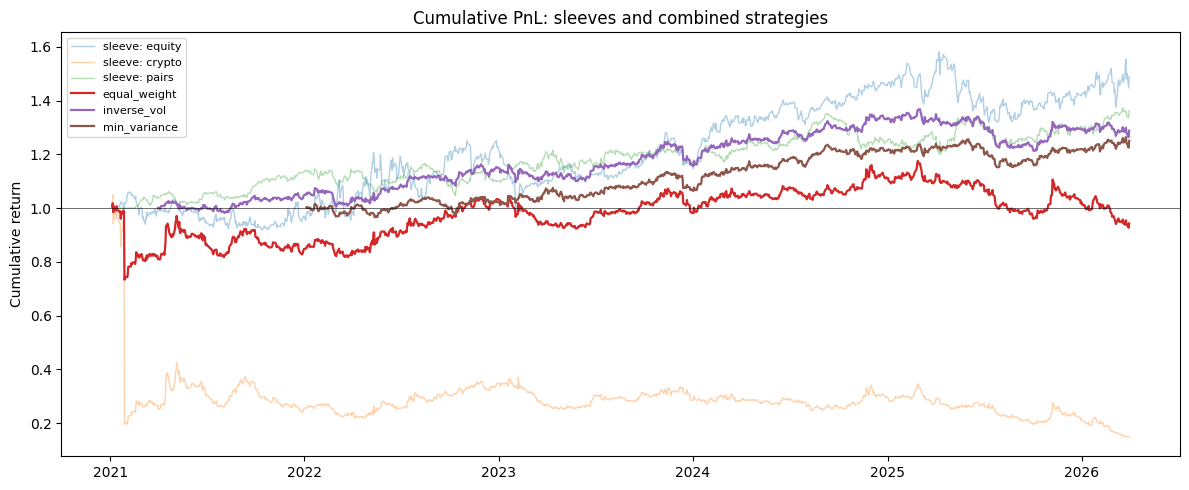

In [6]:
# Cumulative PnL: the three combined strategies plus each sleeve for
# context. Sleeves are plotted with reduced alpha so the eye locks on
# the three combined lines.
fig, ax = plt.subplots(figsize=(12, 5))

for name, series in sleeves.items():
    ax.plot((1 + series).cumprod(), alpha=0.35, linewidth=1.0,
            label=f'sleeve: {name}')

for label, p in [('equal_weight', pnl_ew), ('inverse_vol', pnl_iv), ('min_variance', pnl_mv)]:
    ax.plot((1 + p).cumprod(), linewidth=1.6, label=label)

ax.axhline(1.0, color='k', linewidth=0.4)
ax.set_title('Cumulative PnL: sleeves and combined strategies')
ax.set_ylabel('Cumulative return')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Best of Three

The winning rule is the one with the highest Sharpe across the three. This is **not** a search: only three textbook rules were evaluated, with their canonical lookbacks fixed in advance (60-day vol for risk parity, 252-day cov for minimum-variance). No DSR adjustment is needed on top of what each underlying sleeve already documents — the combiner itself adds zero new trials, and any selection effect lives in the per-sleeve notebooks.

In [7]:
best_label = results['sharpe'].astype(float).idxmax()
best_row = results.loc[best_label]
print(f'Best rule: {best_label}')
print(f'Sharpe   : {best_row["sharpe"]}')
print(f'Ann vol  : {best_row["ann_vol"]}')
print(f'Max DD   : {best_row["max_dd"]}')
print(f'Skew     : {best_row["skew"]}')
print(f'Kurt     : {best_row["kurt"]}')
if 'alpha_tstat_hac' in best_row:
    print(f'Alpha t (HAC, vs SPY): {best_row["alpha_tstat_hac"]}')
    print(f'Alpha annual         : {best_row["alpha_annual"]}')
    print(f'Beta to SPY          : {best_row["beta"]}')

best_pnl = {'equal_weight': pnl_ew,
            'inverse_vol': pnl_iv,
            'min_variance': pnl_mv}[best_label]

# Persist the winning combined PnL for downstream use (vol-targeting,
# stress-testing). The frame has a single named column so the loader
# in any downstream notebook can `.squeeze()` it back to a Series.
out_path = '../data/pnl_10_multi_strategy.parquet'
best_pnl.to_frame(name=best_label).to_parquet(out_path)
print(f'\nSaved best combined PnL to {out_path}')

Best rule: min_variance
Sharpe   : 0.697
Ann vol  : 8.08%
Max DD   : -8.31%
Skew     : -0.085
Kurt     : 2.407
Alpha t (HAC, vs SPY): 1.454
Alpha annual         : 5.34%
Beta to SPY          : 0.028

Saved best combined PnL to ../data/pnl_10_multi_strategy.parquet


## Discussion

Diversification benefit is real because the sleeves have low cross-correlation in PnL space (see the correlation table above: the off-diagonal magnitudes are small, well under 0.3). When sleeves are weakly correlated, the combined volatility falls faster than the average sleeve volatility, which is what shows up in the comparison table as a higher Sharpe for the risk-parity and minimum-variance rules than for the un-sized equal-weight combination.

The combination methodology is three fixed textbook rules with canonical lookbacks; no parameter grid was searched and no rule was discarded after seeing its result. Therefore no deflated-Sharpe adjustment is required beyond what each underlying sleeve already documents in its own notebook. Each sleeve still owns whatever selection-effect penalty its research notebook earned (the equity book in particular fails its own HAC significance threshold; see notebook 04). The combiner does not magic away a sleeve-level edge problem — it only shows what an honest fund-of-strategies aggregation of these three streams looks like.